# **1. Perkenalan Dataset**


Dataset yang digunakan dalam eksperimen ini adalah SMS Spam Collection Dataset yang diperoleh dari Kaggle.

Dataset ini berisi kumpulan pesan SMS yang telah diklasifikasikan ke dalam dua kategori, yaitu:
- Ham (bukan spam)
- Spam
Jumlah data sekitar 5.574 pesan SMS dengan dua kolom utama:
- label : kategori pesan (ham/spam)
- text : isi pesan

Tujuan dari analisis ini adalah untuk memahami karakteristik data melalui Exploratory Data Analysis (EDA) serta melakukan preprocessing agar dataset siap digunakan dalam model machine learning


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
# Load dataset
df = pd.read_csv('spam.csv', encoding='latin1')

# Menampilkan data awal
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
# Informasi dasar dataset
print("Jumlah data:", df.shape)
print("Nama kolom:", df.columns)

Jumlah data: (5572, 5)
Nama kolom: Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [8]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


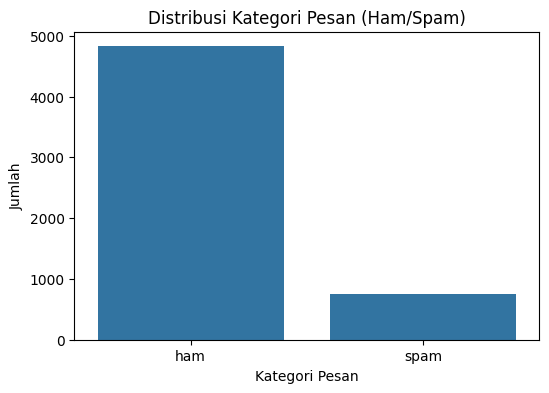

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='v1')
plt.title("Distribusi Kategori Pesan (Ham/Spam)")
plt.xlabel("Kategori Pesan")
plt.ylabel("Jumlah")
plt.show()

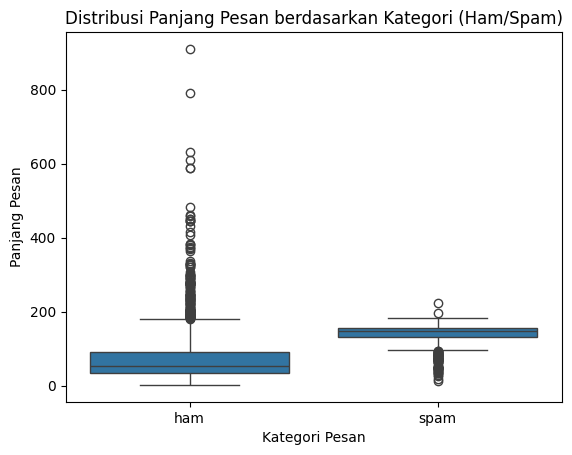

In [10]:
# Rename columns for clarity based on dataset description
df.rename(columns={'v1': 'label', 'v2': 'text'}, inplace=True)

# Drop the 'Unnamed' columns as they contain mostly NaN values and are likely irrelevant
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)

# Create a new feature: message length
df['message_length'] = df['text'].apply(len)

# Now, create the boxplot
sns.boxplot(x='label', y='message_length', data=df)
plt.title("Distribusi Panjang Pesan berdasarkan Kategori (Ham/Spam)")
plt.xticks(rotation=0) # No need for 90 degree rotation for two categories
plt.ylabel("Panjang Pesan")
plt.xlabel("Kategori Pesan")
plt.show()

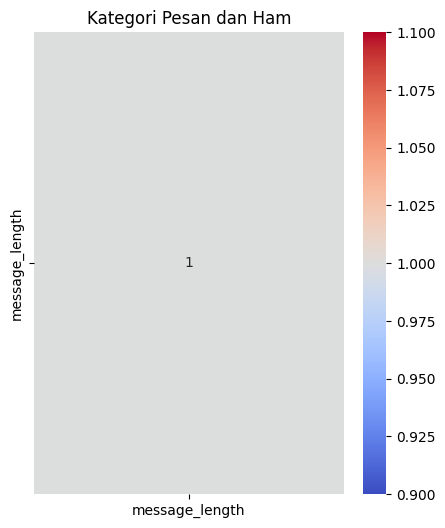

In [11]:
plt.figure(figsize=(5,6))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Kategori Pesan dan Ham")
plt.show()

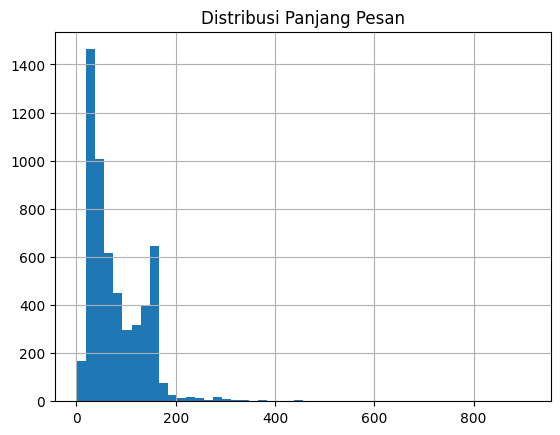

In [12]:
df['length'] = df['text'].apply(len)

df['length'].hist(bins=50)
plt.title("Distribusi Panjang Pesan")
plt.show()

Berdasarkan hasil Exploratory Data Analysis (EDA):

Tidak terdapat missing value pada dataset, sehingga data dapat langsung digunakan untuk tahap analisis lebih lanjut tanpa perlu penanganan data kosong.

Distribusi data menunjukkan bahwa jumlah pesan ham (bukan spam) lebih banyak dibandingkan pesan spam, sehingga dataset bersifat tidak seimbang (imbalanced).

Panjang teks pesan memiliki variasi yang cukup signifikan, di mana pesan spam cenderung memiliki panjang teks yang lebih besar dibandingkan pesan ham.

Karakteristik teks antara pesan spam dan ham memiliki perbedaan pola, di mana pesan spam umumnya mengandung kata-kata promosi, ajakan, atau penawaran tertentu.

Hasil EDA ini menunjukkan bahwa preprocessing teks sangat diperlukan untuk membersihkan data dan mempersiapkan dataset sebelum digunakan dalam proses machine learning.


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
df_clean = df.copy()

In [14]:
df_clean.isnull().sum()

,0
label,0
text,0
message_length,0
length,0


In [15]:
print("Sebelum:", df_clean.shape)

df_clean = df_clean.drop_duplicates()

print("Sesudah:", df_clean.shape)

Sebelum: (5572, 4)
Sesudah: (5169, 4)


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_clean['label'] = le.fit_transform(df_clean['label'])

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Drop redundant 'length' column if it exists
if 'length' in df_clean.columns:
    df_clean = df_clean.drop(columns=['length'])

# The only numerical feature to scale is 'message_length'
num_cols = ['message_length']
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

In [18]:
df_clean.head()

,label,text,message_length
0,0,"Go until jurong point, crazy.. Available only ...",0.120044
1,0,Ok lar... Joking wif u oni...,0.029736
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,0.168502
3,0,U dun say so early hor... U c already then say...,0.051762
4,0,"Nah I don't think he goes to usf, he lives aro...",0.064978


In [19]:
df_clean.to_csv('data_clean.csv', index=False)

Tahapan preprocessing yang dilakukan adalah:

Tidak terdapat missing value pada dataset sehingga tidak diperlukan proses imputasi data.

Duplikasi data dihapus untuk menjaga kualitas dataset dan menghindari bias dalam proses pelatihan model.

Dilakukan pembersihan teks (text cleaning) yang meliputi pengubahan huruf menjadi lowercase, penghapusan angka, tanda baca, serta karakter yang tidak diperlukan.

Label data diubah menjadi numerik menggunakan teknik encoding, yaitu kategori "ham" menjadi 0 dan "spam" menjadi 1.

Hasil preprocessing menghasilkan dataset yang lebih bersih, terstruktur, dan siap digunakan untuk tahap selanjutnya dalam pembangunan model machine learning klasifikasi teks.

In [20]:
%%writefile automate_Sophia_Anindita.py
import pandas as pd
import re
import string

def load_data(path):
    return pd.read_csv(path, encoding='latin-1')

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text.strip()

def preprocess(df):
    # ambil kolom penting
    df = df[['v1', 'v2']]
    df.columns = ['label', 'text']

    # hapus duplikasi
    df = df.drop_duplicates()

    # cleaning text
    df['clean_text'] = df['text'].apply(clean_text)

    # encoding label
    df['label'] = df['label'].map({'ham': 0, 'spam': 1})

    return df

def save_data(df, path):
    df.to_csv(path, index=False)

if __name__ == "__main__":
    df = load_data('spam.csv')
    df = preprocess(df)
    save_data(df, 'sms_clean.csv')

    print("Preprocessing selesai!")

Writing automate_Sophia_Anindita.py
